In [2]:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import os
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap

In [3]:
path = "/Users/sankalpyadava/Desktop/Biocomplexity Institute/va_adult_activity_location_assignment_day.csv-10-of-160"
Adult_Activity_Location = pd.read_csv(path)
Adult_Activity_Location.drop_duplicates(inplace=True)
Adult_Activity_Location.head()

,hid,pid,activity_number,activity_type,start_time,duration,lid,longitude,latitude,travel_mode,distance
0,159884041,361729913,0,1,187200,19080,1125084195,-79.706357,37.233933,-1,0.00000
1,159884041,361729913,2,4,206580,420,2481921,-79.733418,37.207809,-1,3.76554
2,159884041,361729913,4,3,207240,1560,1477904,-79.703815,37.251894,-1,5.55870
3,159884041,361729913,6,1,209040,16200,1125084195,-79.706357,37.233933,-1,2.00984
4,159884041,361729913,8,3,226680,780,1477904,-79.703815,37.251894,-1,2.00984


In [7]:
print(Adult_Activity_Location.shape)

(178151, 11)


In [5]:
filtered = Adult_Activity_Location[Adult_Activity_Location['activity_type'].isin([2, 3, 4])]

DistancePerPerson = (
    filtered
    .groupby(['pid', 'activity_type'])['distance']
    .sum()
    .reset_index(name='total_distance'))

DistancePerPerson.head()
DistancePerPerson.sort_values('total_distance', ascending=False).head()
DistancePerPerson.describe()

,pid,activity_type,total_distance
count,5.284100e+04,52841.000000,52841.000000
mean,3.617538e+08,3.136466,43.452769
std,1.385413e+04,0.853888,177.618057
min,3.617299e+08,2.000000,0.000000
25%,3.617420e+08,2.000000,8.043480
50%,3.617538e+08,3.000000,20.716770
75%,3.617657e+08,4.000000,45.381800
max,3.617782e+08,4.000000,7565.039000


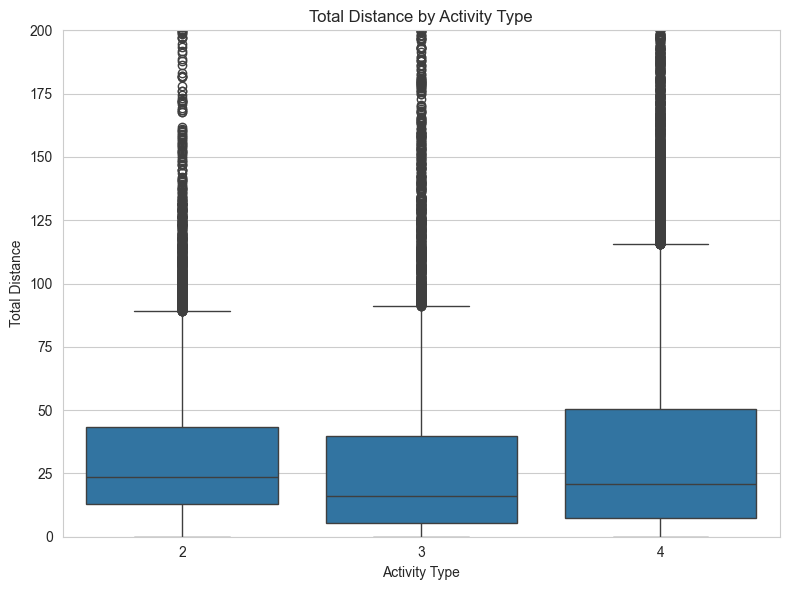

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 6))

sns.boxplot(data=DistancePerPerson, x='activity_type', y='total_distance', ax=ax)

ax.set_ylim(0, 200)
ax.set_title('Total Distance by Activity Type')
ax.set_xlabel('Activity Type')
ax.set_ylabel('Total Distance')

plt.tight_layout()
plt.show()

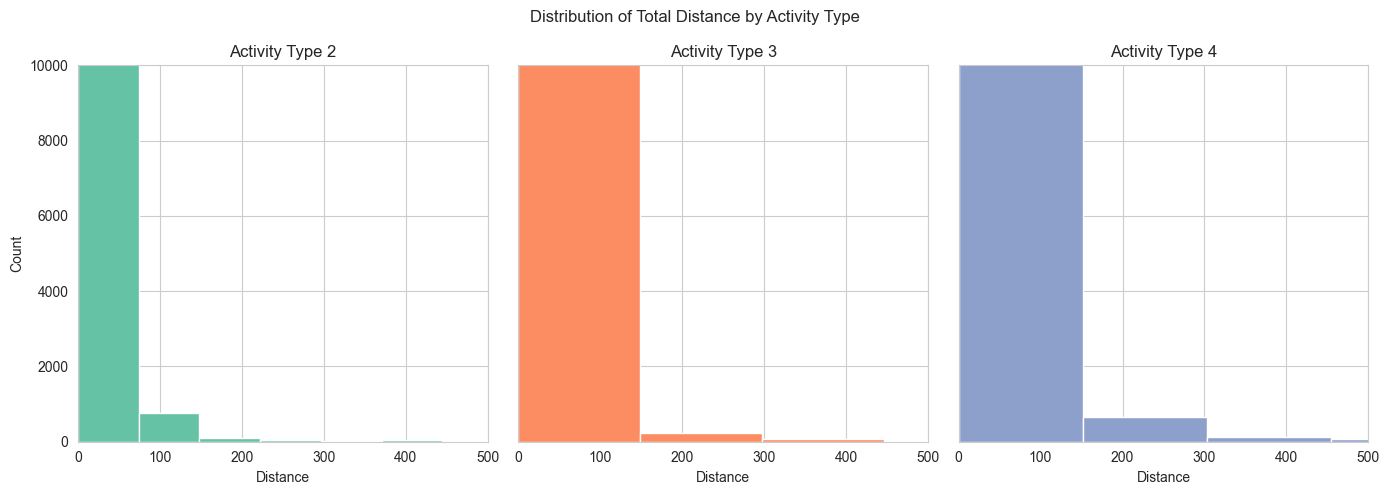

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

activity_labels = {2: 'Activity Type 2', 3: 'Activity Type 3', 4: 'Activity Type 4'}
colors = sns.color_palette('Set2', 3)

for ax, (activity, color) in zip(axes, zip([2, 3, 4], colors)):
    data = DistancePerPerson[DistancePerPerson['activity_type'] == activity]['total_distance']
    ax.hist(data, bins=50, color=color, edgecolor='white')
    ax.set_title(activity_labels[activity])
    ax.set_xlabel('Distance')
    ax.set_xlim(0, 500)
    ax.set_ylim(0, 10000)

axes[0].set_ylabel('Count')

plt.suptitle('Distribution of Total Distance by Activity Type')
plt.tight_layout()
plt.show()

In [32]:
NumVisits = Adult_Activity_Location.groupby(['lid', 'longitude', 'latitude', 'activity_type']).size().reset_index(name='num_visits')
NumVisits.to_csv("/Users/sankalpyadava/Desktop/NumVisits.csv", index=False)

In [34]:
NumVisits.head()

,lid,longitude,latitude,activity_type,num_visits
0,103032,-81.617617,30.309072,4,1
1,136048,-84.380977,33.926421,3,1
2,137357,-84.190482,34.018878,3,1
3,137378,-84.432916,33.659394,4,1
4,192401,-76.951317,38.647861,4,1


In [41]:
NumVisits.groupby('activity_type')['num_visits'].describe()

,count,mean,std,min,25%,50%,75%,max
activity_type,,,,,,,,
1,18693.0,4.402878,2.445325,1.0,3.0,4.0,6.0,99.0
2,9374.0,2.641988,3.913779,1.0,1.0,2.0,3.0,198.0
3,4184.0,4.815010,12.982885,1.0,1.0,2.0,4.0,353.0
4,15262.0,3.083017,6.471613,1.0,1.0,1.0,2.0,100.0
5,378.0,2.343915,7.390813,1.0,1.0,1.0,2.0,101.0
6,94.0,4.861702,10.993254,1.0,1.0,2.0,4.0,99.0
7,723.0,3.513140,6.041021,1.0,1.0,2.0,3.0,100.0


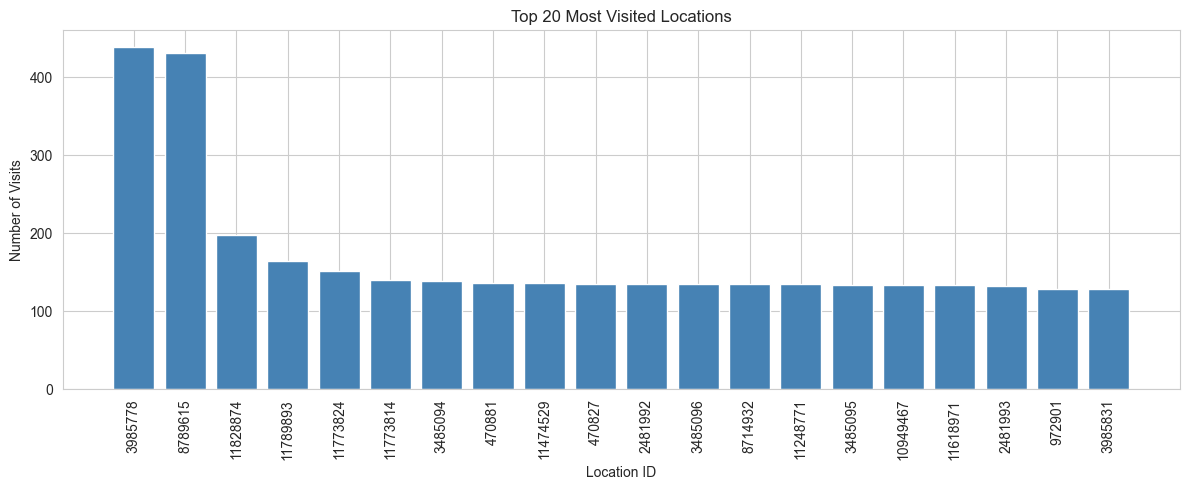

In [6]:
top20 = NumVisits.nlargest(20, 'num_visits')
plt.figure(figsize=(12, 5))
plt.bar(top20['lid'].astype(str), top20['num_visits'], color='steelblue')
plt.xticks(rotation=90)
plt.xlabel('Location ID')
plt.ylabel('Number of Visits')
plt.title('Top 20 Most Visited Locations')
plt.tight_layout()
plt.show()

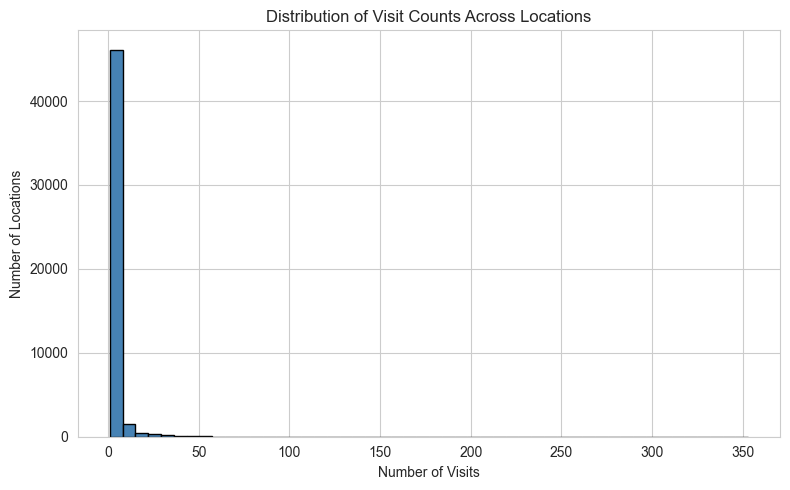

In [45]:
plt.figure(figsize=(8, 5))
plt.scatter(NumVisits['num_visits'], bins=50, color='steelblue', edgecolor='black')
plt.xlabel('Number of Visits')
plt.ylabel('Number of Locations')
plt.title('Distribution of Visit Counts Across Locations')
plt.tight_layout()
plt.show()

In [1]:
m = folium.Map(location=[37.5, -79.0], zoom_start=7)
heat_data = NumVisits[['latitude', 'longitude', 'num_visits']].values.tolist()
HeatMap(heat_data, radius=8, blur=10, max_zoom=13).add_to(m)
m

NameError: name 'folium' is not defined

In [9]:
path2 = "/Users/sankalpyadava/Desktop/Va_location_mapping_with_NAICS.csv"
naics = pd.read_csv(path2)
naics.drop_duplicates(inplace=True)
naics.head()

,source_id,latitude,longitude,mapped_advan_id_store,designation,naics_code,naics2,naics4
0,8793639,38.312266,-77.504701,1739587.0,none,336111.0,33,3361.0
1,3499190,37.040129,-76.340238,NaN,none,NaN,na,NaN
2,10733383,36.789260,-76.111597,NaN,none:medical,NaN,na,NaN
3,8733585,38.149835,-79.071284,NaN,none,NaN,na,NaN
4,4001119,36.863998,-76.396332,NaN,none:retail,NaN,na,NaN


In [10]:
path3 = "/Users/sankalpyadava/Desktop/va_household_residence_assignment.csv"
House = pd.read_csv(path3)
House.drop_duplicates(inplace=True)
House.head()

,hid,rlid,longitude,latitude,altitude,blockgroup_id,admin1,admin2,admin3,admin4,...,pub_04,pub_05,pub_06,pub_07,pub_08,pub_09,pub_10,pub_11,pub_12,associate_link_func_class
0,159646762,1122161814,-75.351597,37.936945,-1,510010901001,51,1,90100,1,...,11773611,11773611,11773612,11773612,11773612,11773612,11773612,11773612,11773612,-1
1,159646541,1122161819,-75.351597,37.936945,-1,510010901001,51,1,90100,1,...,11773611,11773611,11773612,11773612,11773612,11773612,11773612,11773612,11773612,-1
2,159646816,1122161816,-75.351597,37.936945,-1,510010901001,51,1,90100,1,...,11773611,11773611,11773612,11773612,11773612,11773612,11773612,11773612,11773612,-1
3,159646599,1123213253,-75.358702,37.944467,-1,510010901001,51,1,90100,1,...,11773611,11773611,11773612,11773612,11773612,11773612,11773612,11773612,11773612,-1
4,159646637,1123979010,-75.360628,37.943846,-1,510010901001,51,1,90100,1,...,11773611,11773611,11773612,11773612,11773612,11773612,11773612,11773612,11773612,-1


In [11]:
Combined = House.merge(Adult_Activity_Location, on='hid')
Combined.drop_duplicates(inplace=True)

In [12]:
ActivityHouseNaics = Combined.merge(naics, left_on='lid', right_on='source_id')
ActivityHouseNaics.drop_duplicates(inplace=True)
ActivityHouseNaics.head()

,hid,rlid,longitude_x,latitude_x,altitude,blockgroup_id,admin1,admin2,admin3,admin4,...,travel_mode,distance,source_id,latitude,longitude,mapped_advan_id_store,designation,naics_code,naics2,naics4
0,159884114,1122637853,-79.750309,37.232161,-1,510190306011,51,19,30601,1,...,-1,1.50231,972869,37.244865,-79.744533,NaN,none,NaN,na,NaN
1,159884114,1122637853,-79.750309,37.232161,-1,510190306011,51,19,30601,1,...,-1,3.98542,8713197,37.213816,-79.722047,NaN,none:retail,NaN,na,NaN
2,159884189,1124435684,-79.750333,37.231272,-1,510190306011,51,19,30601,1,...,-1,4.68024,1477907,37.193375,-79.727335,NaN,none,NaN,na,NaN
3,159884189,1124435684,-79.750333,37.231272,-1,510190306011,51,19,30601,1,...,-1,3.04603,972868,37.254771,-79.732648,NaN,none:religion,NaN,na,NaN
4,159884350,1123474029,-79.750687,37.229521,-1,510190306011,51,19,30601,1,...,-1,3.96818,2985461,37.196356,-79.734142,NaN,none,NaN,na,NaN


In [13]:
NumVisits2 = ActivityHouseNaics.groupby(['lid', 'longitude', 'latitude']).size().reset_index(name='num_visits')
NumVisits2.to_csv("/Users/sankalpyadava/Desktop/NumVisits2.csv", index=False)

In [14]:
NumVisits2

,lid,longitude,latitude,num_visits
0,469819,-78.478864,38.084588,1
1,469875,-78.507435,38.086443,1
2,470027,-78.495512,37.799843,1
3,470040,-79.830395,37.824513,2
4,470042,-79.802170,37.819408,4
...,...,...,...,...
19213,11678458,-80.422977,37.239583,1
19214,11678478,-79.212728,37.336051,1
19215,11678490,-81.270866,37.255599,1
19216,11678546,-81.416266,37.187607,3


In [15]:
m2 = folium.Map(location=[37.5, -79.0], zoom_start=7)
heat_data = NumVisits2[['latitude', 'longitude', 'num_visits']].values.tolist()
HeatMap(heat_data, radius=8, blur=10, max_zoom=13).add_to(m2)
m2

In [19]:
NumVisits3 = ActivityHouseNaics.groupby(['lid', 'admin1', 'admin2', 'admin3', 'admin4', 'naics_code'])['lid'].count().reset_index(name='num_locations')
NumVisits3.drop_duplicates(inplace=True)
NumVisits3.to_csv("/Users/sankalpyadava/Desktop/NumLocation.csv", index=False)

In [20]:
NumVisits3

,lid,admin1,admin2,admin3,admin4,naics_code,num_locations
0,470027,51,19,30603,2,722513.0,1
1,470043,51,23,40100,3,811111.0,1
2,470043,51,23,40200,3,811111.0,1
3,470043,51,23,40200,4,811111.0,1
4,470043,51,23,40401,1,811111.0,2
...,...,...,...,...,...,...,...
6010,11253453,51,19,30601,3,448150.0,1
6011,11253453,51,19,30604,1,448150.0,1
6012,11253514,51,23,40302,3,423620.0,2
6013,11617964,51,19,30601,2,491110.0,1


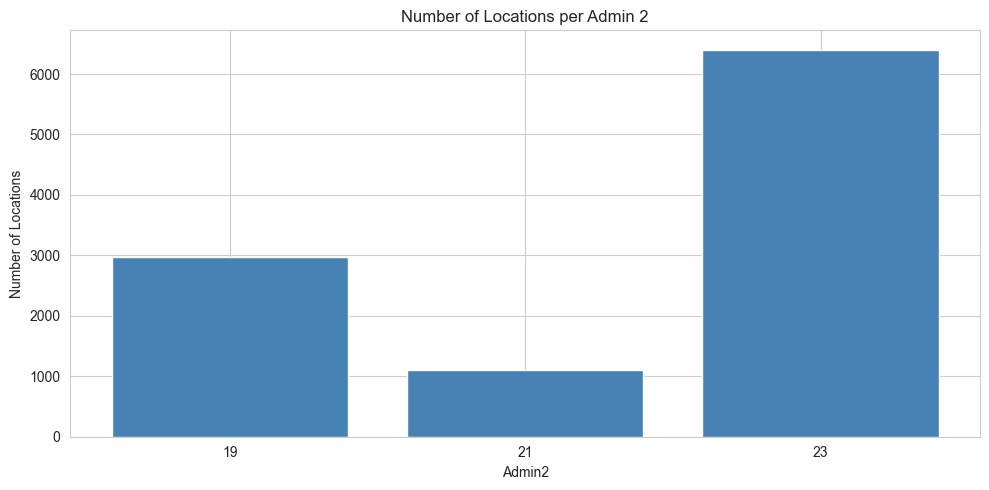

In [21]:
admin2 = NumVisits3.groupby('admin2')['num_locations'].sum().reset_index()
plt.figure(figsize=(10, 5))
plt.bar(admin2['admin2'].astype(str), admin2['num_locations'], color='steelblue')
plt.xlabel('Admin2')
plt.ylabel('Number of Locations')
plt.title('Number of Locations per Admin 2')
plt.tight_layout()
plt.show()

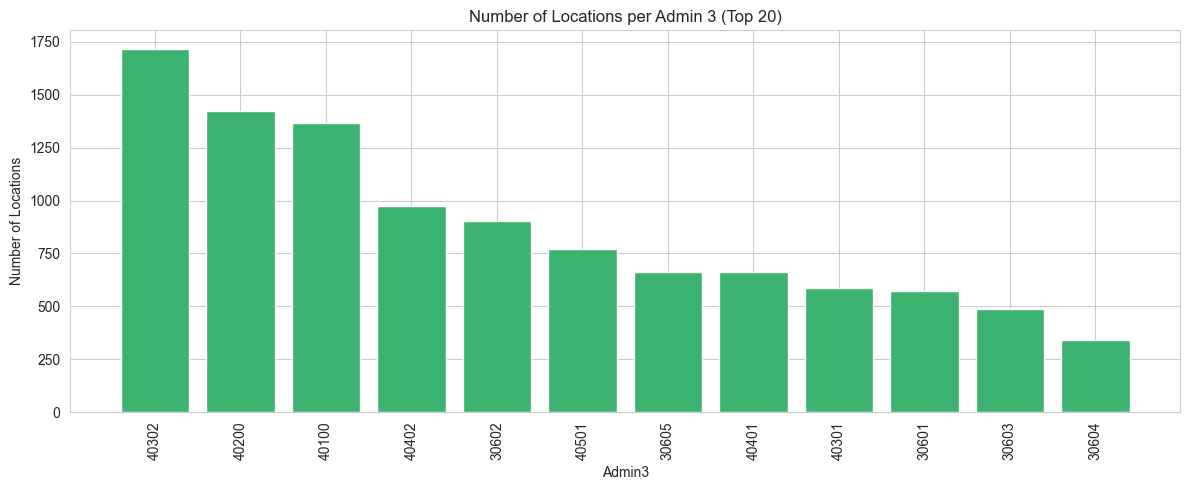

In [22]:
admin3 = NumVisits3.groupby('admin3')['num_locations'].sum().nlargest(20).reset_index()
plt.figure(figsize=(12, 5))
plt.bar(admin3['admin3'].astype(str), admin3['num_locations'], color='mediumseagreen')
plt.xticks(rotation=90)
plt.xlabel('Admin3')
plt.ylabel('Number of Locations')
plt.title('Number of Locations per Admin 3 (Top 20)')
plt.tight_layout()
plt.show()

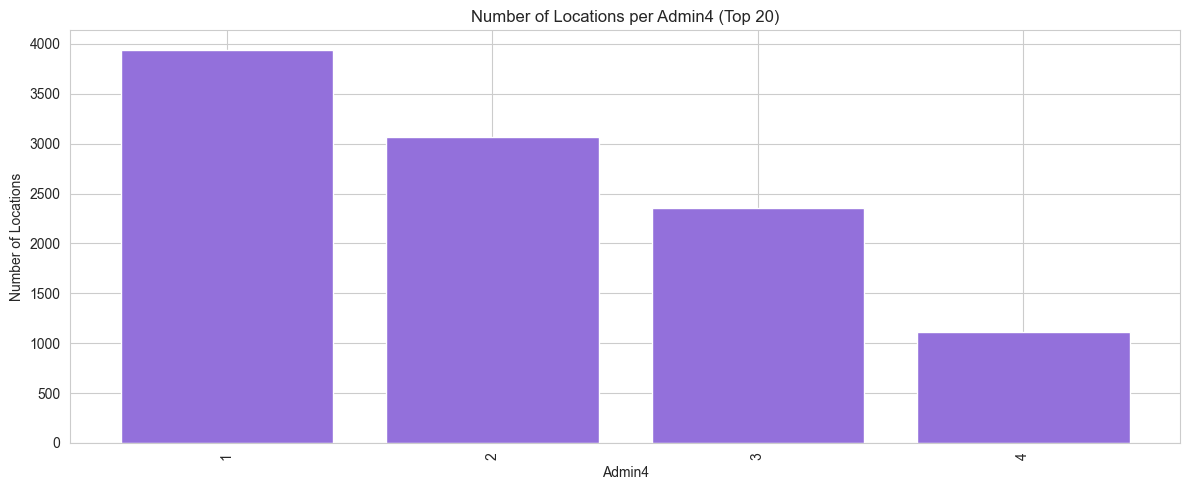

In [23]:
admin4 = NumVisits3.groupby('admin4')['num_locations'].sum().nlargest(20).reset_index()
plt.figure(figsize=(12, 5))
plt.bar(admin4['admin4'].astype(str), admin4['num_locations'], color='mediumpurple')
plt.xticks(rotation=90)
plt.xlabel('Admin4')
plt.ylabel('Number of Locations')
plt.title('Number of Locations per Admin4 (Top 20)')
plt.tight_layout()
plt.show()

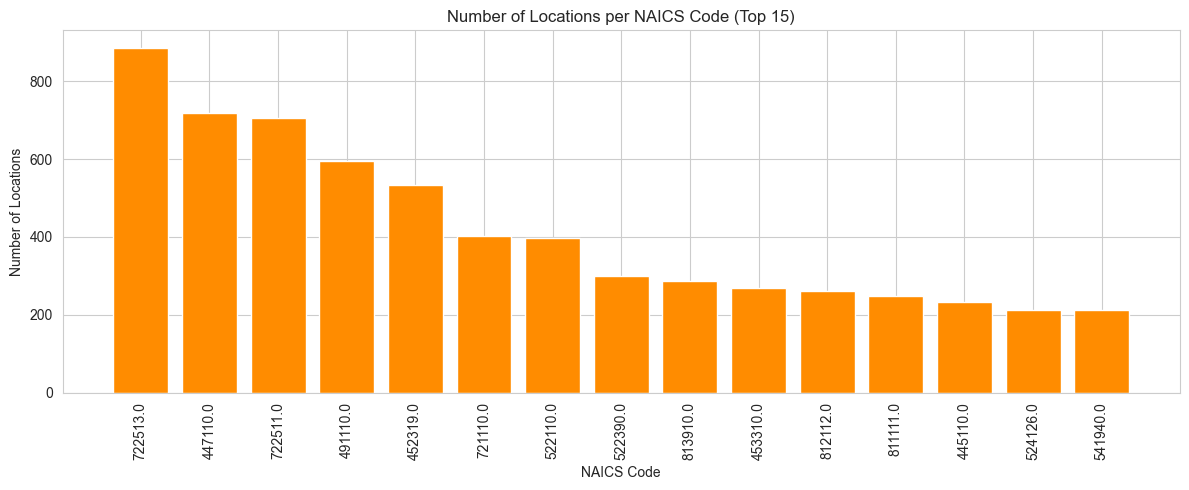

In [24]:
naics_agg = NumVisits3.groupby('naics_code')['num_locations'].sum().nlargest(15).reset_index()
plt.figure(figsize=(12, 5))
plt.bar(naics_agg['naics_code'].astype(str), naics_agg['num_locations'], color='darkorange')
plt.xticks(rotation=90)
plt.xlabel('NAICS Code')
plt.ylabel('Number of Locations')
plt.title('Number of Locations per NAICS Code (Top 15)')
plt.tight_layout()
plt.show()